In [1]:
import numpy as np 

from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

In [2]:
# set up features
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]


In [3]:
# setup bias term
X_with_bias = np.c_[np.ones(len(X)), X]

print(X_with_bias[:5])

[[1.  1.4 0.2]
 [1.  1.4 0.2]
 [1.  1.3 0.2]
 [1.  1.5 0.2]
 [1.  1.4 0.2]]


In [4]:
# split training data
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size  * test_ratio)
train_size = total_size - test_size - validation_size 

np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

In [5]:
# one hot vector 
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

In [6]:
# create the target class probability matrix 
Y_train_to_one_hot = to_one_hot(y_train)
Y_valid_to_one_hot = to_one_hot(y_valid)
Y_test_to_one_hot = to_one_hot(y_test)

In [7]:
# scaling the inputs
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std


In [8]:
# define softmax equation
def softmax(logits):
    exp = np.exp(logits)
    exp_sums = exp.sum (axis=1, keepdims=True)
    return exp / exp_sums
    

In [9]:
# setting up the parameters

n_input = X_train.shape[1]
n_output = len(np.unique(y_train))

In [10]:
# training the model without early stopping
eta = 0.5
n_epoch = 10001 
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_input, n_output)

for epoch in range(n_epoch):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        # training loss 
        train_losses = -(Y_train_to_one_hot * np.log(Y_proba + epsilon))
        train_loss = train_losses.sum(axis=1).mean()
        
        # validation loss
        Y_proba_valid = softmax(X_valid @ Theta)
        xentrophy_losses = -(Y_valid_to_one_hot * np.log(Y_proba_valid + epsilon))
        valid_loss = xentrophy_losses.sum(axis=1).mean()
        
        print(epoch, "train:", round(train_loss, 4), "validation:", round(valid_loss, 4))
    error = Y_proba - Y_train_to_one_hot 
    gradients = 1 / m * X_train.T @ error 
    Theta = Theta - eta * gradients 
    

0 train: 3.7202 validation: 3.7086
1000 train: 0.0766 validation: 0.1452
2000 train: 0.0661 validation: 0.1301
3000 train: 0.0613 validation: 0.1201
4000 train: 0.0583 validation: 0.1137
5000 train: 0.0562 validation: 0.11
6000 train: 0.0546 validation: 0.108
7000 train: 0.0534 validation: 0.1071
8000 train: 0.0524 validation: 0.1068
9000 train: 0.0516 validation: 0.1068
10000 train: 0.051 validation: 0.1071


In [11]:
# Accuracy score with validation set 
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy = (y_predict == y_valid).mean()
print(accuracy)

0.9333333333333333


In [18]:
# training model wiht regularization
eta = 0.5
n_epoch = 10001 
m = len(X_train)
epsilon = 1e-5
alpha = 0.01 

np.random.seed(42)
Theta = np.random.randn(n_input, n_output)

for epoch in range(n_epoch):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentrophy_losses = -(Y_valid_to_one_hot * np.log(Y_proba_valid + epsilon))
        l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
        valid_loss = xentrophy_losses.sum(axis=1).mean() + alpha * l2_loss
        print(epoch, valid_loss.round(4))
    error = Y_proba - Y_train_to_one_hot 
    gradients = 1 / m * X_train.T @ error 
    gradients += np.r_[np.zeros([1, n_output]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients 

0 3.7372
1000 0.3259
2000 0.3259
3000 0.3259
4000 0.3259
5000 0.3259
6000 0.3259
7000 0.3259
8000 0.3259
9000 0.3259
10000 0.3259


In [19]:
# testing new model on validation dataset 
logits = X_valid @ Theta 
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy = (y_predict == y_valid).mean()
print(accuracy) 

0.9333333333333333


In [21]:
eta = 0.5
n_epoch = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_input, n_output)

for epoch in range(n_epoch):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentrophy_losses = -(Y_valid_to_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    valid_loss = xentrophy_losses.sum(axis=1).mean() + alpha * l2_loss
    if epoch % 1000 == 0:
        print(epoch, valid_loss.round(4))
    if valid_loss < best_loss:
        best_loss = valid_loss
    else: 
        print(epoch - 1, best_loss.round(4))
        print(epoch, valid_loss.round(4))
        break
    error = Y_proba - Y_train_to_one_hot 
    gradients = 1 / m * X_train.T @ error 
    gradients += np.r_[np.zeros([1, n_output]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients 

0 3.7372
281 0.3256
282 0.3256


In [23]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy = (y_predict == y_valid).mean()
print(accuracy)

0.9333333333333333


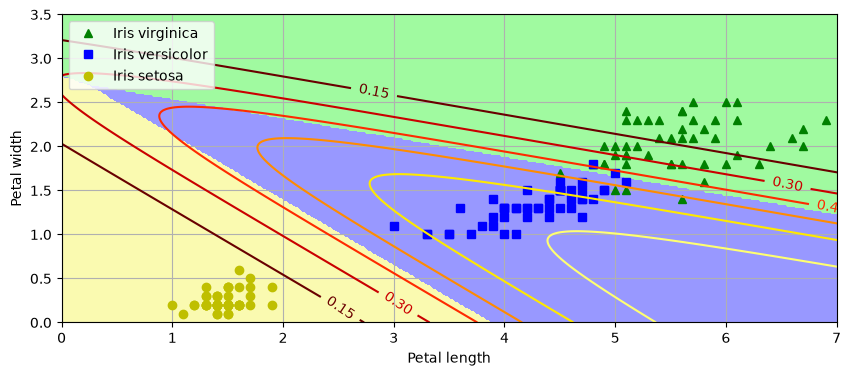

In [25]:
import matplotlib as mpl 
import matplotlib.pyplot as plt 

custom_cmap = mpl.colors.ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()
plt.show()

In [27]:
# run the model on test set
logits = X_test @ Theta 
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy = (y_predict == y_test).mean()
print(accuracy)

0.9666666666666667
